In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from types import SimpleNamespace
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
import matplotlib as mpl
import pandas as pd
from mpmath import fac
from scipy.interpolate import griddata
import h5py
import os
import urllib.request



In [2]:
zenodo_url = "https://zenodo.org/records/21995299/files/sgwb_paper_data.h5?download=1"
dire_out = "."
local_path = os.path.join(dire_out, "sgwb_paper_data.h5")

if not os.path.exists(local_path):
    print(f"Downloading data from Zenodo ({zenodo_url}) ...")
    urllib.request.urlretrieve(zenodo_url, local_path)
    print("Download complete.")

h5f = h5py.File(local_path, "r")

In [3]:
np.random.seed(498)

twocolumnfigsize = (10, 9)
BASE=12
labelsize=11

figure_style = {
    "periodogram": {
        "color": "green",
        "alpha": 0.2,
        "label": "Periodogram",
    },
    "estimated_signal": {
        "color": "orange",
        "alpha": 0.6,
        "label": "Est. Signal",
    },
    "true_noise": {
        "color": "black",
        "linestyle": ":",
        "alpha": 1.0,
        "label": "True Noise",
    },
    "estimated_noise": {
        "color": "red",
        "alpha": 1.0,
        "linewidth": 1.4,
        "label": "Est. Noise",
    },
    "true_signal": {
        "color": "blue",
        "linestyle": "--",
        "label": "True Signal",
    },
}

In [4]:
#some constants
pi = np.pi
c = 299792458
sin = np.sin


def sin2(x):
    return (np.sin(x)) ** 2


cos = np.cos
L = 2.5e9
dt = 2.0  # seconds
fs = 1.0 / dt
atm = 3e-15
aoms = 15e-12

model_names=dict(parwide=r"$\mathcal{M}_{\mathrm{parametric}}^{\mathrm{TM:wide}}$",parinfo=r"$\mathcal{M}_{\mathrm{parametric}}^{\mathrm{TM:info}}$",agnwide=r"$\mathcal{M}_{\mathrm{agnostic}}^{\mathrm{TM:wide}}$",agninfo=
r"$\mathcal{M}_{\mathrm{agnostic}}^{\mathrm{TM:info}}$",
)



In [5]:
'''
Main paper plots:
'''

# LISA noise:
def testmass_psd(atm, f):
    '''
    Testmass theoretical spectrum
    :param atm: testmass parameter
    :param f: frequencies
    :return: testmass PSD
    '''
    f = np.asarray(f, float)
    f = np.clip(f, 1e-12, None)  # dividing by zero
    return (atm)**2 * (1 + (0.4e-3/f)**2) * (1 + (f/8e-3)**4) * (1/(2*pi*f*c))**2

def oms_psd(aoms, f):
    '''
    OMS theoretical spectrum
    :param aoms: OMS parameter
    :param f: frequencies
    :return: OMS PSD
    '''
    f = np.asarray(f, float)
    f = np.clip(f, 1e-12, None) #dividing by zero
    return (aoms)**2 * (1 + (2e-3/f)**4) * (2*pi*f/c)**2

def x_phase(f, L=L, c=c):
    return 2.0 * np.pi * f * (L / c)

def common(f):
    x = x_phase(f)
    return 16.0 * (np.sin(x)**2) * (np.sin(2.0*x)**2)

def A_psd(atm, aoms, f):
    '''
    Theoretical noise spectrum of TDI A channel (Assuming same for E channel)
    :param atm: testmass parameter
    :param aoms: oms parameter
    :param f: frequencies
    :return: TDI A PSD
    '''
    x = x_phase(f)
    tm = 4.0 * common(f) * (3.0 + 2.0*np.cos(x) + np.cos(2.0*x)) * testmass_psd(atm, f)
    om = 2.0 * common(f) * (2.0 + np.cos(x)) * oms_psd(aoms, f)
    return tm + om

def T_psd(atm, aoms, f):
    '''
    Theoretical spectrum of TDI T channel (assuming no signal component in this channel)
    :param atm: testmass parameter
    :param aoms: oms parameter
    :param f: frequencies
    :return: TDI T PSD
    '''

    x = x_phase(f)
    tm = 32.0 * common(f) * (np.sin(0.5*x)**4) * testmass_psd(atm, f)
    om = 4.0 * common(f) * (1.0 - np.cos(x)) * oms_psd(aoms, f)
    return tm + om

def A_psd_tmoms(stm, soms, f):
    '''
    Theoretical TDI A channel noise spectral density in terms of testmass and oms spectral densities
    :param stm: testmass psd
    :param soms: oms psd
    :param f: frequencies
    :return: TDI A PSD
    '''
    x = x_phase(f)
    tm = 4.0 * common(f) * (3.0 + 2.0*np.cos(x) + np.cos(2.0*x)) * stm
    om = 2.0 * common(f) * (2.0 + np.cos(x)) * soms
    return tm + om

def T_psd_tmoms(stm, soms, f):
    '''
    Theoretical TDI T channel spectral density in terms of testmass and oms spectral densities
    :param stm: testmass psd
    :param soms: oms psd
    :param f: frequencies
    :return: TDI T PSD
    '''

    x = x_phase(f)
    tm = 32.0 * common(f) * (np.sin(0.5*x)**4) * stm
    om = 4.0 * common(f) * (1.0 - np.cos(x)) * soms
    return tm + om


def plot_case_block_npz(gs_sub, data, prefix, title, A_spec, sig_A_true,y_limit=[-0.05, 0.05],show_yaxis=True,show_xaxis=True,):
    ax_psd = plt.subplot(gs_sub[0])
    ax_err = plt.subplot(gs_sub[1])

    f = data[f"{prefix}_f"]
    pdgrm = data[f"{prefix}_pdgrm"]
    n_low, n_high = data[f"{prefix}_noise_low"], data[f"{prefix}_noise_high"]
    s_low, s_high = data[f"{prefix}_sig_low"], data[f"{prefix}_sig_high"]

    # PSD plot
    ax_psd.plot(f,pdgrm,**figure_style["periodogram"])
    ax_psd.fill_between(f,s_low,s_high,**figure_style["estimated_signal"],)
    ax_psd.plot(f,A_spec,**figure_style["true_noise"],)
    ax_psd.fill_between(f,n_low,n_high,**figure_style["estimated_noise"],)
    ax_psd.plot(f,sig_A_true,**figure_style["true_signal"],)

    ax_psd.set_xscale("log")
    ax_psd.set_yscale("log")
    ax_psd.set_xlim(f.min(), f.max())
    ax_psd.text(0.5, 0.94, title,
            transform=ax_psd.transAxes,
            fontsize=BASE,
            ha='center', va='top',
            color='black',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='none', alpha=0.75))
    ax_psd.set_ylim(1e-51, 1e-38)
    ax_psd.tick_params(which="both", direction="in", top=True, right=True, labelsize=BASE)
    ax_psd.tick_params(axis="x", which="both", labelbottom=False,)

    # Relative error
    err_low_n = (np.log(n_low) - np.log(A_spec)) / np.abs(np.log(A_spec))
    err_high_n = (np.log(n_high) - np.log(A_spec)) / np.abs(np.log(A_spec))

    err_low_s = (np.log(s_low) - np.log(sig_A_true)) / np.abs(np.log(sig_A_true))
    err_high_s = (np.log(s_high) - np.log(sig_A_true)) / np.abs(np.log(sig_A_true))

    ax_err.fill_between(f, err_low_n, err_high_n, color='red', alpha=0.35)
    ax_err.fill_between(f, err_low_s, err_high_s, color='orange', alpha=0.35)
    ax_err.tick_params(which="both", direction="in", top=True, right=True, labelsize=BASE)
    ax_err.axhline(0, color="black", lw=1, ls=":")
    ax_err.set_xscale("log")
    ax_err.set_xlim(10 ** np.floor(np.log10(f.min())), f.max())
    ax_err.set_ylim(y_limit)
    if show_yaxis:
        ax_psd.set_ylabel("PSD [1/Hz]", fontsize=labelsize)
        ax_err.set_ylabel(r"$\Delta_{\text{rel},\text{X}}(f)$",fontsize=labelsize)
    else:
        ax_psd.set_ylabel("")
        ax_err.set_ylabel("")
        ax_psd.tick_params(axis="y",which="both",labelleft=False,)
        ax_err.tick_params(axis="y",which="both",labelleft=False,)
    if show_xaxis:
        ax_err.set_xlabel("f [Hz]",fontsize=labelsize)
        ax_err.tick_params(axis="x",which="both",labelbottom=True,)
    else:
        ax_err.set_xlabel("")
        ax_err.tick_params(axis="x",which="both",labelbottom=False,)

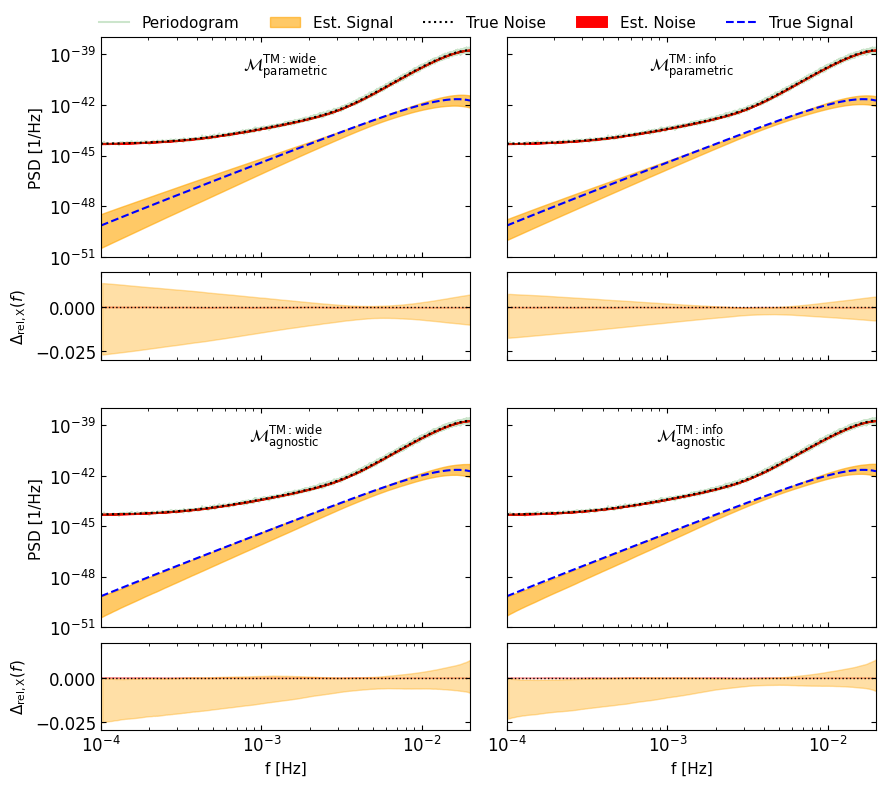

In [6]:

f_fit = h5f["shared/f_seg"][:]
A_spec = h5f["shared/A_spec"][:]
sig_A_spec = h5f["shared/sig_A_spec_pl"][:]
data = {k: v[:] for k, v in h5f["pl"].items()}

prefixes = ["bayes_w", "bayes_i", "np_w", "np_i"]


titles = [
    model_names['parwide'],
    model_names['parinfo'],
    model_names["agnwide"],
    model_names["agninfo"],
]
fig = plt.figure(figsize=twocolumnfigsize)
outer_grid = gridspec.GridSpec(2, 2, wspace=0.1, hspace=0.15)

for i, pref in enumerate(prefixes):
    column = i % 2
    row = i // 2
    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1,
                                                  subplot_spec=outer_grid[i],
                                                  height_ratios=[3, 1.2],
                                                  hspace=0.1)

    plot_case_block_npz(inner_grid, data, pref, titles[i], A_spec, sig_A_spec,y_limit=[-0.03, 0.02], show_yaxis=(column == 0),show_xaxis=(row == 1),)

handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.92),
           ncol=5, frameon=False, fontsize=labelsize)
plt.show()

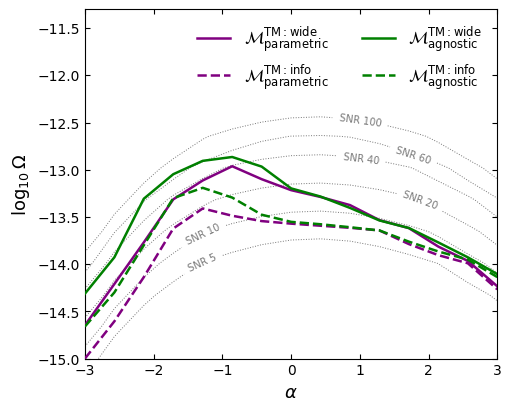

In [7]:
def _threshold_boundary(data, level=2.0):

    alphas = np.unique(data["n"])
    boundary = np.full(alphas.shape, np.nan, dtype=float)
    y_all = np.log10(data["omega"])
    for i, alpha in enumerate(alphas):
        mask = data["n"] == alpha
        order = np.argsort(y_all[mask])
        y = y_all[mask][order]
        z = data["log10B"][mask][order]
        crossings = np.flatnonzero((z[:-1] - level) * (z[1:] - level) <= 0)
        if crossings.size:
            j = crossings[0]
            boundary[i] = y[j] + (level - z[j]) * (y[j + 1] - y[j]) / (z[j + 1] - z[j])
        elif np.all(z > level):
            boundary[i] = y[0]
    return alphas, boundary


def _regular_grid(data, key):
    alphas = np.unique(data["n"])
    log_omega = np.unique(np.log10(data["omega"]))
    values = np.full((log_omega.size, alphas.size), np.nan)
    alpha_index = {v: i for i, v in enumerate(alphas)}
    omega_index = {v: i for i, v in enumerate(log_omega)}
    for alpha, omega, value in zip(data["n"], np.log10(data["omega"]), data[key]):
        values[omega_index[omega], alpha_index[alpha]] = value
    return alphas, log_omega, values


cases = [
    {"file": "paramwide",    "label": model_names["parwide"],   "color": "purple", "ls": "-"},
    {"file": "paraminfo",    "label": model_names["parinfo"],   "color": "purple", "ls": "--"},
    {"file": "nonparamwide", "label": model_names["agnwide"],  "color": "green", "ls": "-"},
    {"file": "nonparaminfo", "label": model_names["agninfo"],  "color": "green", "ls": "--"},
]

bf_data = {}
for case in cases:
    grp = h5f[f"bayes_factors/{case['file']}"]
    bf_data[case["file"]] = {
        "n": grp["n"][:],
        "omega": grp["omega"][:],
        "log10B": grp["log10B"][:],
        "snr": grp["snr"][:],
    }

fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")

alpha_grid, omega_grid, snr_grid = _regular_grid(bf_data[cases[0]["file"]], "snr")
snr_contours = ax.contour(
    alpha_grid, omega_grid, snr_grid,
    levels=[5, 10, 20, 40, 60, 100],
    colors="#777777",
    linewidths=0.7,
    linestyles=":",
    zorder=1,
)
snr_labels = ax.clabel(
        snr_contours,
        inline=True,
        fontsize=7.2,
        fmt=lambda value: f"SNR {value:g}",
        manual=[(-1.29, -13.98), (-1.29, -13.67), (1.88, -13.32),(1, -13.0),(1.8, -12.8),(1, -12.5)],
    )
for snr_label in snr_labels:
        snr_label.set_bbox(
            {"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 0.25}
        )

# Threshold boundary for each model
for case in cases:
    alpha, boundary = _threshold_boundary(bf_data[case["file"]])
    ax.plot(
        alpha, boundary,
        color=case["color"],
        ls=case["ls"],
        lw=1.8,
        ms=3.8,
        label=case["label"],
        zorder=3,
    )

ax.set_xlabel(r"$\alpha$", fontsize=13)
ax.set_ylabel(r"$\log_{10}\Omega$", fontsize=13)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.legend(loc="upper right", ncol=2, frameon=False, fontsize=12)
plt.show()

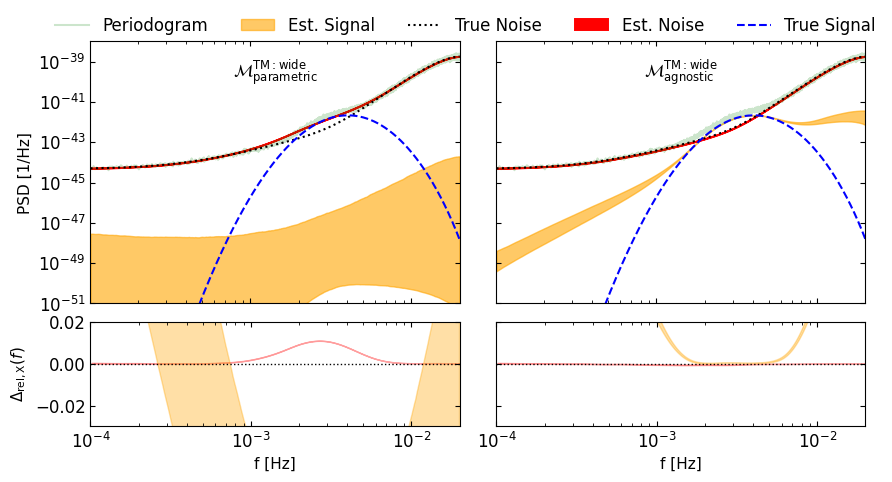

In [8]:
sig_A_spec = h5f["shared/sig_A_spec_gb"][:]
data = {k: v[:] for k, v in h5f["gb"].items()}

prefixes = ["bayes_w", "np_w"]

titles = [
    model_names['parwide'],
    model_names['agnwide'],
]

fig = plt.figure(figsize=(10, 5))
outer_grid = gridspec.GridSpec(1, 2, wspace=0.1, hspace=0.15)

for i, pref in enumerate(prefixes):
    column = i % 2
    row = i // 2
    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1,
                                                  subplot_spec=outer_grid[i],
                                                  height_ratios=[3, 1.2],
                                                  hspace=0.1)

    plot_case_block_npz(inner_grid, data, pref, titles[i], A_spec, sig_A_spec,y_limit=[-0.03, 0.02], show_yaxis=(column == 0),show_xaxis=(row == 0),)


handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96),
           ncol=5, frameon=False, fontsize=BASE)
plt.show()

In [9]:
'''
Appendix plots
'''
#colours
COLOR_TM   = "grey"
COLOR_OMS  = "black"
COLOR_BASE = "black"
ALPHA_BAND = 0.35

def _apply_band_axes_style(ax_band, ax_rel, a, ylabel_band=False, ylabel_rel=False):
    # Top panel
    ax_band.tick_params(which="both", direction="in", top=True, right=True, labelsize=BASE)
    if ylabel_band:
        ax_band.set_ylabel("PSD [Hz$^{-1}$]", fontsize=10)

    # Bottom panel
    ax_rel.tick_params(which="both", direction="in", top=True, right=True, labelsize=BASE)
    ax_rel.axhline(0.0, ls=":", lw=1.0, color=COLOR_BASE, zorder=3)
    ax_rel.set_ylim([-(a / 100 + 0.02), (a / 100 + 0.02)])

    pct = a / 100
    ax_rel.set_yticks([-pct, 0, pct])
    ax_rel.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:+.0%}")
    )
    if ylabel_rel:
        ax_rel.set_ylabel(r"$\Delta_{C}(f)$", fontsize=10)


def band_plot_col(stm_true, soms_true, f, NT_fun,
                  perturb, label, color, a,
                  ax_band, ax_rel, channel):

    NT_base = NT_fun(stm=stm_true, soms=soms_true, f=f)

    if perturb == "stm":
        NT_low  = NT_fun(stm=(1 - a/100) * stm_true, soms=soms_true, f=f)
        NT_high = NT_fun(stm=(1 + a/100) * stm_true, soms=soms_true, f=f)
    else:
        NT_low  = NT_fun(stm=stm_true, soms=(1 - a/100) * soms_true, f=f)
        NT_high = NT_fun(stm=stm_true, soms=(1 + a/100) * soms_true, f=f)

    ax_band.fill_between(f, NT_low, NT_high,
                         color=color, alpha=ALPHA_BAND,
                         label=fr"{label} $\pm{a}\%$ band")
    ax_band.plot(f, NT_base,
                 color=COLOR_BASE, lw=1.2, zorder=4, ls='--',
                 label=fr"${channel}$ theoretical PSD")
    ax_band.set_xscale("log")
    ax_band.set_yscale("log")
    ax_band.legend(frameon=True, framealpha=0.7,
                   edgecolor="lightgray", fontsize=8)
    ax_band.set_xlim(10 ** np.floor(np.log10(f.min())), f.max())
    ax_rel.set_xlim(10 ** np.floor(np.log10(f.min())), f.max())
    diff_low  = (NT_low  - NT_base) / NT_base
    diff_high = (NT_high - NT_base) / NT_base
    ax_rel.fill_between(f, diff_low, diff_high,
                        color=color, alpha=ALPHA_BAND + 0.1)
    ax_rel.set_xscale("log")

def plot_perturb_combined(stm_true, soms_true, freq,
                           NT_fun_A, NT_fun_T, a):
    fig = plt.figure(figsize=(9, 10))

    gs = GridSpec(
        4, 2,
        figure=fig,
        height_ratios=[3, 1, 3, 1],
        hspace=0.08,
        wspace=0.15,
    )

    ax_A_tm   = fig.add_subplot(gs[0, 0])
    ax_Ar_tm  = fig.add_subplot(gs[1, 0], sharex=ax_A_tm)
    ax_A_oms  = fig.add_subplot(gs[0, 1])
    ax_Ar_oms = fig.add_subplot(gs[1, 1], sharex=ax_A_oms)

    ax_T_tm   = fig.add_subplot(gs[2, 0])
    ax_Tr_tm  = fig.add_subplot(gs[3, 0], sharex=ax_T_tm)
    ax_T_oms  = fig.add_subplot(gs[2, 1])
    ax_Tr_oms = fig.add_subplot(gs[3, 1], sharex=ax_T_oms)

    band_plot_col(stm_true, soms_true, freq, NT_fun_A,
                  perturb="stm", label=r"$S_{\rm TM}$", color=COLOR_TM,
                  a=a, ax_band=ax_A_tm, ax_rel=ax_Ar_tm, channel="A")
    band_plot_col(stm_true, soms_true, freq, NT_fun_A,
                  perturb="oms", label=r"$S_{\rm OMS}$", color=COLOR_OMS,
                  a=a, ax_band=ax_A_oms, ax_rel=ax_Ar_oms, channel="A")
    band_plot_col(stm_true, soms_true, freq, NT_fun_T,
                  perturb="stm", label=r"$S_{\rm TM}$", color=COLOR_TM,
                  a=a, ax_band=ax_T_tm, ax_rel=ax_Tr_tm, channel="T")
    band_plot_col(stm_true, soms_true, freq, NT_fun_T,
                  perturb="oms", label=r"$S_{\rm OMS}$", color=COLOR_OMS,
                  a=a, ax_band=ax_T_oms, ax_rel=ax_Tr_oms, channel="T")

    _apply_band_axes_style(ax_A_tm,  ax_Ar_tm,  a, ylabel_band=True,  ylabel_rel=True)
    _apply_band_axes_style(ax_A_oms, ax_Ar_oms, a, ylabel_band=False, ylabel_rel=False)
    _apply_band_axes_style(ax_T_tm,  ax_Tr_tm,  a, ylabel_band=True,  ylabel_rel=True)
    _apply_band_axes_style(ax_T_oms, ax_Tr_oms, a, ylabel_band=False, ylabel_rel=False)

    ax_A_oms.sharey(ax_A_tm)
    ax_T_oms.sharey(ax_T_tm)
    ax_Ar_oms.sharey(ax_Ar_tm)
    ax_Tr_oms.sharey(ax_Tr_tm)

    for ax in (ax_A_oms, ax_T_oms, ax_Ar_oms, ax_Tr_oms):
        plt.setp(ax.get_yticklabels(), visible=False)
    for ax in (ax_A_tm, ax_A_oms, ax_Ar_tm, ax_Ar_oms, ax_T_tm, ax_T_oms):
        plt.setp(ax.get_xticklabels(), visible=False)

    for ax in (ax_Tr_tm, ax_Tr_oms):
        ax.set_xlabel(r"$f$ [Hz]", fontsize=10)

    ax_A_tm.set_title(r"$S_{\rm TM}$ perturbation", fontsize=10)
    ax_A_oms.set_title(r"$S_{\rm OMS}$ perturbation", fontsize=10)
    fig.canvas.draw()
    plt.show()


def contri_plot(freq, pct_stm, pct_soms, channel, ax):
    ax.stackplot(freq, pct_stm, pct_soms,
                 labels=[r'$S_{\rm TM}$', r'$S_{\rm OMS}$'],
                 colors=[COLOR_TM, COLOR_OMS],
                 alpha=ALPHA_BAND+0.2)

    ax.set_xscale('log')
    ax.set_xlabel(r'$f$ [Hz]', fontsize=13)
    ax.set_ylim(0, 100)
    ax.set_xlim(10 ** np.floor(np.log10(freq.min())), freq.max())
    ax.set_title(f'Channel ${channel}$', fontsize=13)
    ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=BASE)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.legend(loc='upper right', frameon=True, framealpha=0.7,
              edgecolor='lightgray', fontsize=12)


def plot_contri_two_subplots(freq, stm_true, soms_true):
    x = x_phase(freq)
    c = common(freq)

    tm_A = 4.0 * c * (3.0 + 2.0*np.cos(x) + np.cos(2.0*x)) * stm_true
    om_A = 2.0 * c * (2.0 + np.cos(x)) * soms_true
    A    = tm_A + om_A
    pct_stm_A  = 100.0 * tm_A / A
    pct_soms_A = 100.0 * om_A / A

    tm_T = 32.0 * c * (np.sin(0.5*x)**4) * stm_true
    om_T =  4.0 * c * (1.0 - np.cos(x)) * soms_true
    T    = tm_T + om_T
    pct_stm_T  = 100.0 * tm_T / T
    pct_soms_T = 100.0 * om_T / T

    fig, axs = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

    contri_plot(freq=freq, pct_stm=pct_stm_A, pct_soms=pct_soms_A,
                channel='A', ax=axs[0])
    contri_plot(freq=freq, pct_stm=pct_stm_T, pct_soms=pct_soms_T,
                channel='T', ax=axs[1])

    axs[0].set_ylabel('Contribution', fontsize=12)
    plt.setp(axs[1].get_yticklabels(), visible=False)
    plt.show()


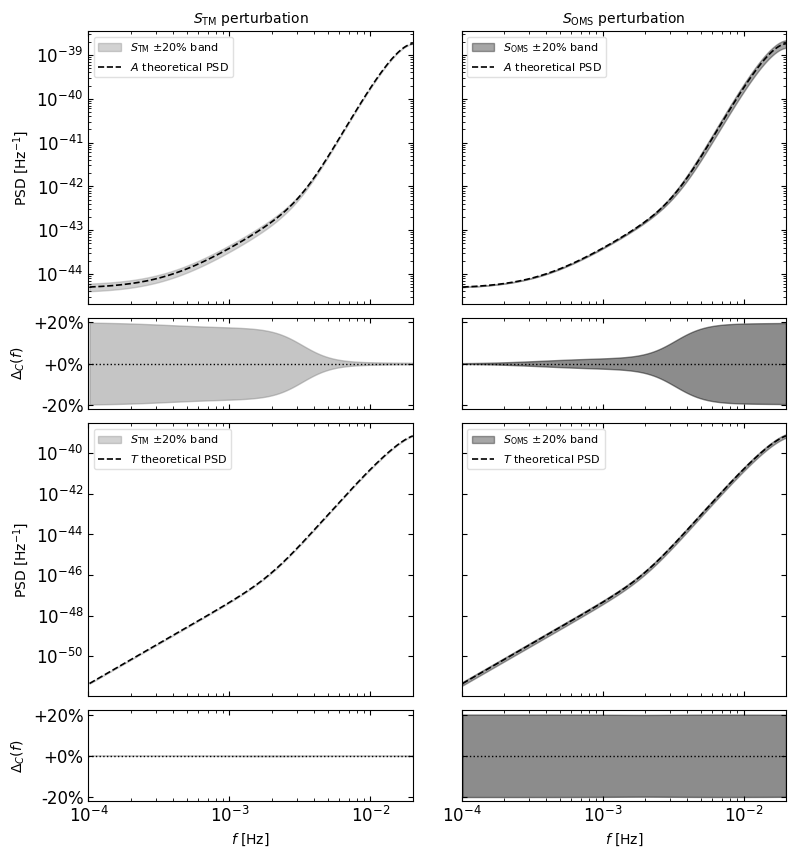

In [10]:
stm_true=testmass_psd(atm, f_fit)
soms_true=oms_psd(aoms, f_fit)


# 20% perturbations
plot_perturb_combined(stm_true, soms_true, f_fit,
                      NT_fun_A=A_psd_tmoms,
                      NT_fun_T=T_psd_tmoms,
                      a=20)

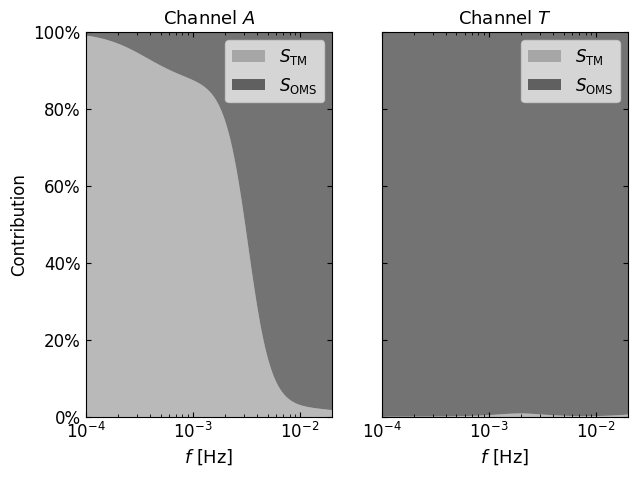

In [11]:
plot_contri_two_subplots(freq=f_fit, stm_true=stm_true, soms_true=soms_true)

In [12]:
'''
Appendix B plot
'''
def prior_psd_bands(
    basis_matrix,
    penalty_matrix,
    weights_loc,
    phi_values,tm_spec,
    n_samples=2000,
    q=(16, 84),
    seed=1234,

):
    B = np.asarray(basis_matrix, dtype=float)
    w0 = np.asarray(weights_loc, dtype=float)
    P = np.asarray(penalty_matrix, dtype=float)

    P_reg = 0.5 * (P + P.T) + 1e-6 * np.eye(P.shape[0])
    L = np.linalg.cholesky(np.linalg.inv(P_reg))

    rng = np.random.default_rng(seed)
    z = rng.standard_normal((n_samples, P.shape[0]))
    base = z @ L.T

    bands = {}
    for phi in phi_values:
        samples = w0 + base / np.sqrt(phi)
        prior_signals = np.exp(samples @ B.T)
        lo, med, hi = np.percentile(prior_signals, [q[0], 50, q[1]], axis=0)
        bands[phi] = {"lower": lo, "median": med, "upper": hi}
    return bands


def plot_phi_bands(f, tm_spec, phi_values, bands):
    phi_sorted = sorted(phi_values)
    band_colors = ["#c9d6df","#8fa3ad","#4a5b66"]
    edge_color = "#2b2b2b"
    band_linewidths = [0, 0, 2.0]

    fig, ax = plt.subplots(figsize=(7, 5))
    for phi, color, lw in zip(phi_sorted, band_colors, band_linewidths):
        band = bands[phi]
        ax.fill_between(f, band["lower"], band["upper"],
                     facecolor=color, edgecolor=color if lw else "none",
                     linewidth=lw, alpha=0.85, zorder=2,
                     label=rf"$\phi = 10^{{{int(np.log10(phi))}}}$")

    ax.loglog(f, tm_spec, color="black", ls="--", lw=0.9,
          label="Theoretical spectrum", alpha=0.9, zorder=3)

    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlabel(r"$f$ [Hz]", fontsize=13)
    ax.set_ylabel(r"PSD [Hz$^{-1}$]", fontsize=13)
    ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=BASE)
    ax.legend(loc="upper right", fontsize=12, framealpha=0.5)
    ax.set_xlim(10 ** np.floor(np.log10(f.min())), f.max())
    plt.tight_layout()
    plt.show()




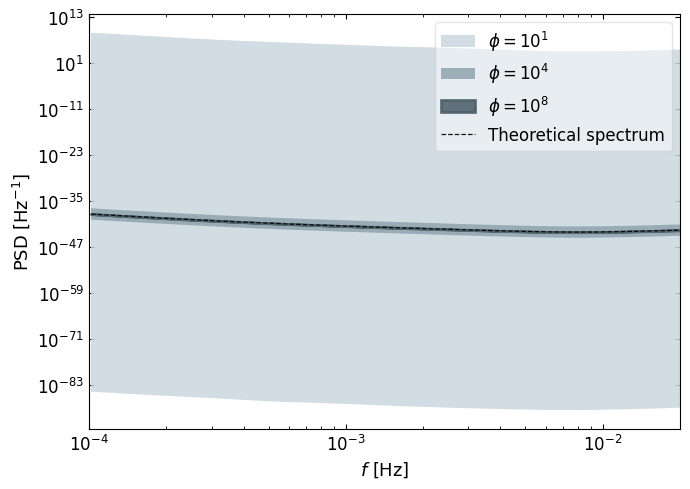

In [13]:
phi_values = [10,1e4, 1e8]
weights_loc = h5f["prior_psd/weights_loc"][:]
basis_matrix = h5f["prior_psd/basis_matrix"][:]
tm_spec = h5f["prior_psd/tm_spec"][:]
penalty_matrix = h5f["prior_psd/penalty_matrix"][:]

bands = prior_psd_bands(
        basis_matrix, penalty_matrix, weights_loc, phi_values,
        n_samples=4000, q=(5, 95), tm_spec=tm_spec,
    )

plot_phi_bands(f_fit, tm_spec, phi_values, bands)

